### Environment Setup

In [8]:
%pip install pyspark findspark

Note: you may need to restart the kernel to use updated packages.


## PySpark Connection

### Load Required Libraries

In [23]:
import os
import shutil
from pathlib import Path
import findspark
import matplotlib.pyplot as plt

def detect_spark_home() -> str:
    spark_home = os.environ.get("SPARK_HOME")
    if spark_home and Path(spark_home).exists():
        return spark_home

    spark_submit = shutil.which("spark-submit") or shutil.which("spark-submit.cmd")
    if spark_submit:
        return str(Path(spark_submit).resolve().parent.parent)

    candidates = [
        r"C:\Spark\spark-4.1.1-bin-hadoop3",
        r"C:\spark\spark-4.1.1-bin-hadoop3",
    ]
    for candidate in candidates:
        if Path(candidate).exists():
            return candidate

    raise EnvironmentError("Spark installation was not found. Set SPARK_HOME once in system variables.")

spark_home = detect_spark_home()
hadoop_home = os.environ.get("HADOOP_HOME", spark_home)

os.environ["SPARK_HOME"] = spark_home
os.environ["HADOOP_HOME"] = hadoop_home
os.environ["hadoop.home.dir"] = hadoop_home

findspark.init(spark_home)
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date, count, when, sum as _sum, round, year, month, avg, upper

In [ ]:
spark = SparkSession\
    .builder\
    .master('local[2]')\
    .appName('myapp')\
    .config('spark.jars.packages', 'com.mysql:mysql-connector-j:8.0.33')\
    .config('spark.hadoop.hadoop.home.dir', os.environ['HADOOP_HOME'])\
    .config('spark.driverEnv.HADOOP_HOME', os.environ['HADOOP_HOME'])\
    .config('spark.executorEnv.HADOOP_HOME', os.environ['HADOOP_HOME'])\
    .getOrCreate()

### Data Extraction from MySQL

In [24]:
df_ecommerce_db = spark.read.format('jdbc').\
            option('url', 'jdbc:mysql://localhost:3306/ecommerce_db').\
            option('driver', 'com.mysql.cj.jdbc.Driver').\
            option('user', 'testuser').\
            option('password', '1234').\
            option('dbtable', 'ecommerce_orders').\
            load()

In [12]:
df_ecommerce_db.show(5)

+-------------------+----------+--------------------+----------+-------------+-------------+-------+---------------+-------------+----+----------+--------------+--------+--------+------+-----------+-----------+-----------+-------+---+------------+
|           order_id|order_date|              status|fulfilment|sales_channel|service_level|  style|            sku|     category|size|      asin|courier_status|quantity|currency|amount|       city|      state|postal_code|country|b2b|fulfilled_by|
+-------------------+----------+--------------------+----------+-------------+-------------+-------+---------------+-------------+----+----------+--------------+--------+--------+------+-----------+-----------+-----------+-------+---+------------+
|405-8078784-5731545|2022-04-30|           Cancelled|  Merchant|    Amazon.in|     Standard| SET389| SET389-KR-NP-S|          Set|   S|B09KXVBD7Z|          NULL|       0|     INR|647.62|     MUMBAI|MAHARASHTRA|     400081|     IN|  0|   Easy Ship|
|171-919

### Data Transformation

### Select Required Columns

In [25]:
# Clean and prepare the data
df_refined = df_ecommerce_db.select(
    col("order_id"),
    col("order_date"),
    col("category"),
    col("amount"),
    col("quantity"),
    col("state"),
    col("status"),
    col("b2b")
)

df_refined = df_refined.withColumn("order_date", to_date(col("order_date"), "MM-dd-yy"))
df_refined = df_refined.withColumn("year", year(col("order_date")))
df_refined = df_refined.withColumn("month", month(col("order_date")))

# remove invalid rows (negative or null values)
df_refined = df_refined.filter(
    col("amount").isNotNull()
    & col("quantity").isNotNull()
    & (col("amount") > 0)
    & (col("quantity") > 0)
)

df_refined = df_refined.withColumn("state", upper(col("state")))

df_refined.printSchema()
df_refined.show(5)

root
 |-- order_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- category: string (nullable = true)
 |-- amount: float (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- state: string (nullable = true)
 |-- status: string (nullable = true)
 |-- b2b: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)

+-------------------+----------+--------+------+--------+-------------+--------------------+---+----+-----+
|           order_id|order_date|category|amount|quantity|        state|              status|b2b|year|month|
+-------------------+----------+--------+------+--------+-------------+--------------------+---+----+-----+
|171-9198151-1101146|2022-04-30|   kurta| 406.0|       1|    KARNATAKA|Shipped - Deliver...|  0|2022|    4|
|404-0687676-7273146|2022-04-30|   kurta| 329.0|       1|  MAHARASHTRA|             Shipped|  1|2022|    4|
|407-1069790-7240320|2022-04-30|     Top| 574.0|       1|   TAMIL NADU|

### Exploratory Data Analysis

In [26]:
print("Null Value Report:")
df_refined.select([count(when(col(c).isNull(), c)).alias(c) for c in df_refined.columns]).show()

print("Statistical Summary:")
df_refined.select("amount", "quantity").describe().show()

print("Order Status Distribution:")
df_refined.groupBy("status").count().orderBy("count", ascending=False).show()

print("Delivered vs Cancelled Orders:")
df_cancel_rate = df_refined.groupBy("status").count()
df_cancel_rate.show()

print("Orders Per Category:")
df_refined.groupBy("category").count().orderBy("count", ascending=False).show()

Null Value Report:
+--------+----------+--------+------+--------+-----+------+---+----+-----+
|order_id|order_date|category|amount|quantity|state|status|b2b|year|month|
+--------+----------+--------+------+--------+-----+------+---+----+-----+
|       0|         0|       0|     0|       0|   28|     0|  0|   0|    0|
+--------+----------+--------+------+--------+-----+------+---+----+-----+

Statistical Summary:
+-------+------------------+-------------------+
|summary|            amount|           quantity|
+-------+------------------+-------------------+
|  count|            113701|             113701|
|   mean| 663.1648446363708| 1.0038522088635984|
| stddev|269.53807391933645|0.07338485032928604|
|    min|             199.0|                  1|
|    max|            5584.0|                  8|
+-------+------------------+-------------------+

Order Status Distribution:
+--------------------+-----+
|              status|count|
+--------------------+-----+
|             Shipped|76078|

### Data Aggregation

In [27]:
df_category_summary = df_refined.groupBy("category") \
    .agg(
        _sum("quantity").alias("total_items_sold"),
        round(_sum("amount"), 2).alias("total_revenue")
    ) \
    .orderBy("total_revenue", ascending=False)

df_state_summary = df_refined.groupBy("state") \
    .agg(
        round(_sum("amount"), 2).alias("total_revenue"),
        _sum("quantity").alias("total_quantity")
    ) \
    .orderBy("total_revenue", ascending=False)

df_monthly_summary = df_refined.groupBy("year", "month") \
    .agg(
        round(_sum("amount"), 2).alias("total_revenue"),
        _sum("quantity").alias("total_quantity")
    ) \
    .orderBy("year", "month")

df_b2b_summary = df_refined.groupBy("b2b") \
    .agg(round(_sum("amount"), 2).alias("total_revenue")) \
    .orderBy("total_revenue", ascending=False)

df_avg_order = df_refined.agg(avg("amount").alias("avg_order_value"))

print("Business Insight: Sales by Category")
df_category_summary.show()

print("Business Insight: Revenue by State")
df_state_summary.show()

print("Business Insight: Monthly Sales Trend")
df_monthly_summary.show()

# calculate monthly trend for analysis
print("Business Insight: Average Order Value")
df_avg_order.show()

print("Business Insight: B2B vs Non-B2B Revenue")
df_b2b_summary.show()

Business Insight: Sales by Category
+-------------+----------------+-------------+
|     category|total_items_sold|total_revenue|
+-------------+----------------+-------------+
|          Set|           44212|  3.7662424E7|
|        kurta|           44112|  2.0452141E7|
|Western Dress|           13708|  1.0629096E7|
|          Top|            9725|    5203733.0|
| Ethnic Dress|            1021|     760711.0|
|       Blouse|             822|     434751.0|
|       Bottom|             385|     140226.0|
|        Saree|             151|     118509.0|
|      Dupatta|               3|        915.0|
+-------------+----------------+-------------+

Business Insight: Revenue by State
+--------------+-------------+--------------+
|         state|total_revenue|total_quantity|
+--------------+-------------+--------------+
|   MAHARASHTRA|  1.2864511E7|         19894|
|     KARNATAKA|    1.01531E7|         15571|
|     TELANGANA|    6642955.0|         10088|
| UTTAR PRADESH|    6494393.0|          9

### Data Visualizations

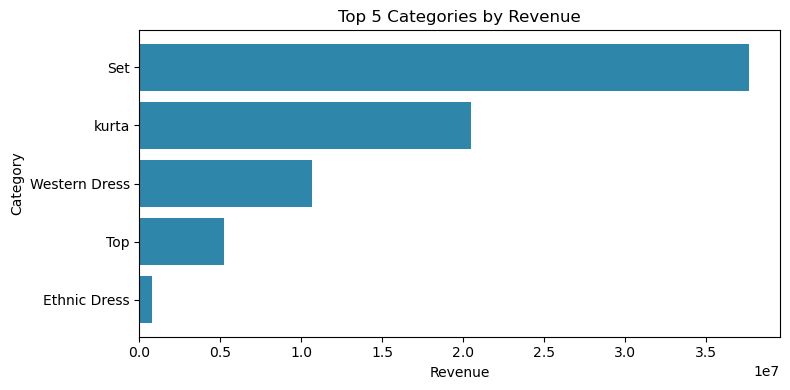

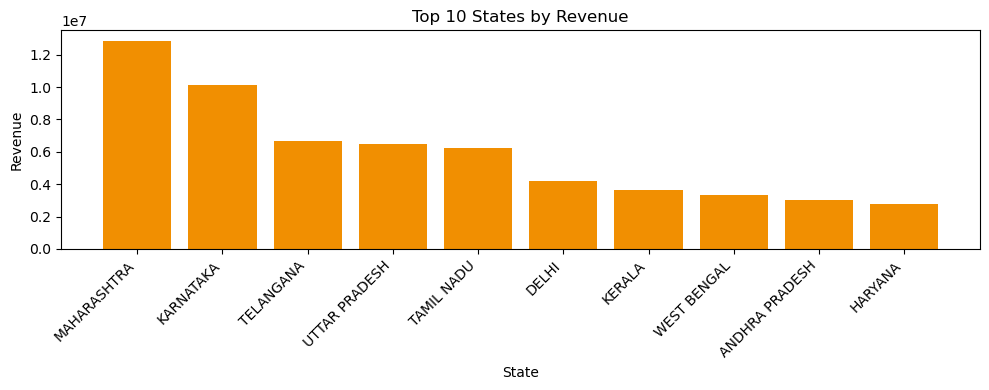

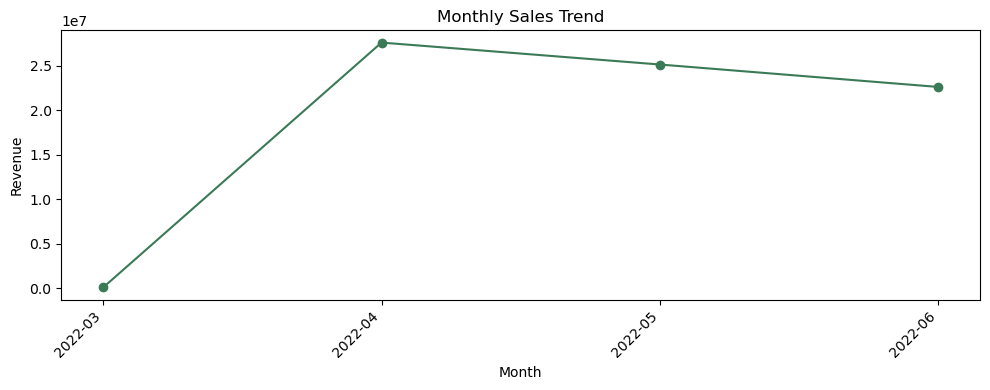

In [29]:
# Top categories by revenue
category_plot = df_category_summary.toPandas().head(5)
plt.figure(figsize=(8, 4))
plt.barh(category_plot["category"], category_plot["total_revenue"], color="#2E86AB")
plt.gca().invert_yaxis()
plt.title("Top 5 Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Revenue by state
state_plot = df_state_summary.toPandas().head(10)
plt.figure(figsize=(10, 4))
plt.bar(state_plot["state"], state_plot["total_revenue"], color="#F18F01")
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Monthly sales trend
monthly_plot = df_monthly_summary.toPandas()
monthly_plot["month_label"] = monthly_plot["year"].astype(str) + "-" + monthly_plot["month"].astype(str).str.zfill(2)
plt.figure(figsize=(10, 4))
plt.plot(monthly_plot["month_label"], monthly_plot["total_revenue"], marker="o", color="#3B7A57")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Data Loading

In [28]:
df_category_summary.write \
    .format("jdbc") \
    .option("url", "jdbc:mysql://localhost:3306/ecommerce_db") \
    .option("driver", "com.mysql.cj.jdbc.Driver") \
    .option("user", "testuser") \
    .option("password", "1234") \
    .option("dbtable", "category_sales_summary") \
    .mode("overwrite") \
    .save()

df_state_summary.write \
    .format("jdbc") \
    .option("url", "jdbc:mysql://localhost:3306/ecommerce_db") \
    .option("driver", "com.mysql.cj.jdbc.Driver") \
    .option("user", "testuser") \
    .option("password", "1234") \
    .option("dbtable", "state_sales_summary") \
    .mode("overwrite") \
    .save()

df_monthly_summary.write \
    .format("jdbc") \
    .option("url", "jdbc:mysql://localhost:3306/ecommerce_db") \
    .option("driver", "com.mysql.cj.jdbc.Driver") \
    .option("user", "testuser") \
    .option("password", "1234") \
    .option("dbtable", "monthly_sales_summary") \
    .mode("overwrite") \
    .save()

print("Assignment complete. Summary tables saved to MySQL.")

Assignment complete. Summary tables saved to MySQL.
